# Hyperparameter Tuning: CNN Traffic Density & Incident Classifier

This notebook conducts a **structured grid search** over the hyperparameter space described in Section 2.5.2 of the project report. Each configuration is trained for **15 epochs** on the training set and validated on the held-out validation set. The best-performing configuration is then retrained from scratch for the full **25 epochs**.

### Search Space

| Hyperparameter | Values Searched |
|---|---|
| Learning rate | 0.001, 0.0005, 0.0001 |
| Batch size | 32, 64, 128 |
| Dropout rate | 0.3, 0.4, 0.5 |
| Optimiser | Adam, SGD w/ Momentum (0.9) |
| Weight decay | 1e-4, 5e-4, 1e-3 |
| LR schedule | CosineAnnealingLR, StepLR, CosineAnnealingWarmRestarts (SGDR) |

## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import itertools
import json
import time
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## 2. Dataset Loading

Augmentation applied **only** to the training split. Validation and test sets use deterministic transforms identical to the baseline. Mixup augmentation (alpha=0.2) is applied inline during the training loop — see Section 5.

In [2]:
data_dir = 'merged_dataset'

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names   = image_datasets['train'].classes
num_classes   = len(class_names)

print('Classes:', class_names)
print('Dataset sizes:', dataset_sizes)

Classes: ['heavy', 'incident', 'light', 'moderate']
Dataset sizes: {'train': 3767, 'val': 438, 'test': 417}


## 3. Class-Imbalance Weights

Computed once from the training split and reused across all grid-search runs.

In [3]:
train_labels  = [label for _, label in image_datasets['train'].samples]
class_counts  = Counter(train_labels)
total_samples = sum(class_counts.values())

class_weights = [
    total_samples / (num_classes * class_counts[i])
    for i in range(num_classes)
]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print('Class counts:',  dict(zip(class_names, [class_counts[i] for i in range(num_classes)])))
print('Class weights:', dict(zip(class_names, [round(w, 4) for w in class_weights])))

Class counts: {'heavy': 743, 'incident': 210, 'light': 2124, 'moderate': 690}
Class weights: {'heavy': 1.2675, 'incident': 4.4845, 'light': 0.4434, 'moderate': 1.3649}


## 4. Model Architecture

The architecture mirrors the baseline CNN but parameterises the **dropout rate** so it can be varied during the grid search.

In [4]:
class TunableCNN(nn.Module):
    """Baseline CNN with a configurable dropout rate."""

    def __init__(self, num_classes: int = 4, dropout_rate: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),   # → 32×64×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # → 64×32×32
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # → 128×16×16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Quick sanity check
dummy = torch.zeros(2, 3, 128, 128)
test_model = TunableCNN(num_classes=num_classes)
print('Output shape:', test_model(dummy).shape)  # Expected: [2, num_classes]

Output shape: torch.Size([2, 4])


## 5. Helper Functions

### 5.1 Mixup Augmentation

Mixup (Zhang et al., 2018) linearly interpolates pairs of training examples and their labels. When combined with SGDR this encourages the optimiser toward flatter loss-landscape minima.

In [5]:
def mixup_data(x, y, alpha: float = 0.2):
    """Returns mixed inputs, pairs of targets, and the mixing coefficient λ."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

### 5.2 Optimiser & Scheduler Factory

In [6]:
def build_optimizer(model, config: dict):
    """Instantiate optimiser from config dict."""
    lr           = config['lr']
    weight_decay = config['weight_decay']
    opt_name     = config['optimizer']

    if opt_name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == 'SGD':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f'Unknown optimiser: {opt_name}')


def build_scheduler(optimizer, config: dict, num_epochs: int):
    """Instantiate LR scheduler from config dict."""
    schedule = config['lr_schedule']
    lr       = config['lr']

    if schedule == 'CosineAnnealingLR':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    elif schedule == 'StepLR':
        # Decay by 0.1 every 5 epochs
        return optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    elif schedule == 'CosineAnnealingWarmRestarts':
        # T_0=5 → restart every 5 epochs (SGDR, Loshchilov & Hutter, 2017)
        return optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=lr * 0.01)
    else:
        raise ValueError(f'Unknown schedule: {schedule}')

### 5.3 Single Training Run

In [17]:
def train_one_config(
    config: dict,
    num_epochs: int = 15,
    use_mixup: bool = True,
    mixup_alpha: float = 0.2,
    verbose: bool = True,
):
    """
    Train the TunableCNN for num_epochs given a hyperparameter config dict.
    Uses Automatic Mixed Precision (AMP) when running on CUDA (RTX 2070).

    Returns
    -------
    dict : best_val_acc, history (train/val loss + acc per epoch), best_weights
    """
    batch_size   = config['batch_size']
    dropout_rate = config['dropout_rate']

    loaders = {
        split: DataLoader(
            image_datasets[split],
            batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=2
        )
        for split in ['train', 'val']
    }

    model     = TunableCNN(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config, num_epochs)
    scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))  # AMP scaler

    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())
    history  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        if verbose:
            print(f'  Epoch {epoch+1:02d}/{num_epochs}', end='')

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss     = 0.0
            running_corrects = 0

            for inputs, labels in loaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                with torch.set_grad_enabled(phase == 'train'):
                    with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                        if phase == 'train' and use_mixup:
                            mixed_inputs, y_a, y_b, lam = mixup_data(inputs, labels, alpha=mixup_alpha)
                            outputs = model(mixed_inputs)
                            loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                        else:
                            outputs = model(inputs)
                            loss    = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()
                        optimizer.zero_grad()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = (running_corrects.float() / dataset_sizes[phase]).item()

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())

        history['lr'].append(scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else optimizer.param_groups[0]['lr'])
        scheduler.step()

        if verbose:
            print(f'  →  val_loss={history["val_loss"][-1]:.4f}  val_acc={history["val_acc"][-1]:.4f}')

    return {
        'best_val_acc': best_acc,
        'history':      history,
        'best_weights': best_wts,
    }

## 6. Grid Search

All combinations of the hyperparameter grid are evaluated. Results are logged to `grid_search_results.json` so the search can be resumed if interrupted.

In [18]:
GRID = {
    'lr':           [0.001, 0.0005, 0.0001],
    'batch_size':   [32, 64, 128],
    'dropout_rate': [0.3, 0.4, 0.5],
    'optimizer':    ['Adam', 'SGD'],
    'weight_decay': [1e-4, 5e-4, 1e-3],
    'lr_schedule':  ['CosineAnnealingLR', 'StepLR', 'CosineAnnealingWarmRestarts'],
}

GRID_SEARCH_EPOCHS = 15
RESULTS_FILE       = 'grid_search_results.json'

# Build all combos
keys   = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f'Total configurations: {len(combos)}')

# Load previously saved results if the search was interrupted
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
    print(f'Resuming — {len(all_results)} runs already completed.')
else:
    all_results = []

Total configurations: 486
Resuming — 26 runs already completed.


In [19]:
from tqdm import tqdm

completed_configs = {json.dumps(r['config'], sort_keys=True) for r in all_results}

for idx, combo in enumerate(tqdm(combos, desc="Grid Search Progress")):
    config = dict(zip(keys, combo))
    config_key = json.dumps(config, sort_keys=True)

    if config_key in completed_configs:
        continue  # Already evaluated

    tqdm.write(f'\n[{idx+1}/{len(combos)}] Config: {config}')
    t0 = time.time()

    result = train_one_config(
        config,
        num_epochs=GRID_SEARCH_EPOCHS,
        use_mixup=True,
        verbose=True
    )

    elapsed = time.time() - t0
    tqdm.write(f'Best val acc: {result["best_val_acc"]:.4f}  ({elapsed:.0f}s)')

    # Persist (exclude model weights from JSON)
    all_results.append({
        'config':       config,
        'best_val_acc': result['best_val_acc'],
        'history':      {k: v for k, v in result['history'].items()},
        'elapsed_s':    elapsed,
    })

    with open(RESULTS_FILE, 'w') as f:
        json.dump(all_results, f, indent=2)

print('\nGrid search complete.')


Grid Search Progress:   0%|          | 0/486 [00:00<?, ?it/s]C:\Users\sarth\AppData\Local\Temp\ipykernel_11996\2557066631.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))  # AMP scaler



[27/486] Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.4, 'optimizer': 'Adam', 'weight_decay': 0.001, 'lr_schedule': 'CosineAnnealingWarmRestarts'}
  Epoch 01/15  →  val_loss=1.0337  val_acc=0.6119
  Epoch 02/15  →  val_loss=0.6798  val_acc=0.7078
  Epoch 03/15  →  val_loss=0.5851  val_acc=0.7626
  Epoch 04/15  →  val_loss=0.6155  val_acc=0.7557
  Epoch 05/15  →  val_loss=0.5666  val_acc=0.7785
  Epoch 06/15  →  val_loss=0.5566  val_acc=0.7557
  Epoch 07/15  →  val_loss=0.5235  val_acc=0.7763
  Epoch 08/15  →  val_loss=0.5764  val_acc=0.7694
  Epoch 09/15  →  val_loss=0.4867  val_acc=0.8105
  Epoch 10/15  →  val_loss=0.4815  val_acc=0.7808
  Epoch 11/15  →  val_loss=0.5949  val_acc=0.7329
  Epoch 12/15  →  val_loss=0.6085  val_acc=0.7192
  Epoch 13/15  →  val_loss=0.5556  val_acc=0.7580
  Epoch 14/15  →  val_loss=0.4945  val_acc=0.7900
  Epoch 15/15  →  val_loss=0.4695  val_acc=0.8037


Grid Search Progress:   6%|▌         | 27/486 [01:22<23:30,  3.07s/it]

Best val acc: 0.8105  (83s)

[28/486] Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.4, 'optimizer': 'SGD', 'weight_decay': 0.0001, 'lr_schedule': 'CosineAnnealingLR'}
  Epoch 01/15  →  val_loss=1.3074  val_acc=0.2900
  Epoch 02/15  →  val_loss=0.9430  val_acc=0.6324
  Epoch 03/15  →  val_loss=0.7688  val_acc=0.7032
  Epoch 04/15  →  val_loss=0.6991  val_acc=0.7237
  Epoch 05/15  →  val_loss=0.6403  val_acc=0.7717
  Epoch 06/15  →  val_loss=0.7152  val_acc=0.6712
  Epoch 07/15  →  val_loss=0.6525  val_acc=0.7397
  Epoch 08/15  →  val_loss=0.5550  val_acc=0.7831
  Epoch 09/15  →  val_loss=0.6459  val_acc=0.7283
  Epoch 10/15  →  val_loss=0.5891  val_acc=0.7717
  Epoch 11/15  →  val_loss=0.5839  val_acc=0.7785
  Epoch 12/15  →  val_loss=0.5697  val_acc=0.7740
  Epoch 13/15  →  val_loss=0.5445  val_acc=0.7854
  Epoch 14/15  →  val_loss=0.5374  val_acc=0.7831
  Epoch 15/15  →  val_loss=0.5363  val_acc=0.7854


Grid Search Progress:   6%|▌         | 28/486 [02:45<54:00,  7.08s/it]

...

Best val acc: 0.7854  (79s)

[53/486] Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.5, 'optimizer': 'SGD', 'weight_decay': 0.001, 'lr_schedule': 'StepLR'}
  Epoch 01/15  →  val_loss=1.1885  val_acc=0.4886
  Epoch 02/15  →  val_loss=0.9888  val_acc=0.6712
  Epoch 03/15  →  val_loss=0.8949  val_acc=0.5548
  Epoch 04/15  →  val_loss=0.7779  val_acc=0.6986
  Epoch 05/15  →  val_loss=0.7715  val_acc=0.6667
  Epoch 06/15  →  val_loss=0.7615  val_acc=0.6963
  Epoch 07/15  →  val_loss=0.7053  val_acc=0.7352
  Epoch 08/15  →  val_loss=0.7075  val_acc=0.7260
  Epoch 09/15  →  val_loss=0.7005  val_acc=0.7169
  Epoch 10/15  →  val_loss=0.6771  val_acc=0.7237
  Epoch 11/15  →  val_loss=0.6758  val_acc=0.7329
  Epoch 12/15  →  val_loss=0.6746  val_acc=0.7306
  Epoch 13/15  →  val_loss=0.6809  val_acc=0.7306
  Epoch 14/15  →  val_loss=0.6750  val_acc=0.7329
  Epoch 15/15  →  val_loss=0.6783  val_acc=0.7283


Grid Search Progress:  11%|█         | 53/486 [37:00<9:49:41, 81.71s/it]

Best val acc: 0.7352  (82s)

[54/486] Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.5, 'optimizer': 'SGD', 'weight_decay': 0.001, 'lr_schedule': 'CosineAnnealingWarmRestarts'}
  Epoch 01/15

Grid Search Progress:  11%|█         | 53/486 [37:03<5:02:49, 41.96s/it]


KeyboardInterrupt: 

Interrupting and updating the grids based on the hyperparameters so far

In [20]:
GRID = {
    'lr':           [0.001, 0.0005, 0.0001],
    'batch_size':   [32, 64, 128],
    'dropout_rate': [0.3, 0.4, 0.5],
    'optimizer':    ['Adam'],
    'weight_decay': [1e-4, 5e-4],
    'lr_schedule':  ['CosineAnnealingLR', 'CosineAnnealingWarmRestarts'],
}

GRID_SEARCH_EPOCHS = 15
RESULTS_FILE       = 'grid_search_results.json'

# Build all combos
keys   = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f'Total configurations: {len(combos)}')

# Load previously saved results if the search was interrupted
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
    print(f'Resuming — {len(all_results)} runs already completed.')
else:
    all_results = []

Total configurations: 108
Resuming — 53 runs already completed.


In [21]:
from tqdm import tqdm

completed_configs = {json.dumps(r['config'], sort_keys=True) for r in all_results}

for idx, combo in enumerate(tqdm(combos, desc="Grid Search Progress")):
    config = dict(zip(keys, combo))
    config_key = json.dumps(config, sort_keys=True)

    if config_key in completed_configs:
        continue  # Already evaluated

    tqdm.write(f'\n[{idx+1}/{len(combos)}] Config: {config}')
    t0 = time.time()

    result = train_one_config(
        config,
        num_epochs=GRID_SEARCH_EPOCHS,
        use_mixup=True,
        verbose=True
    )

    elapsed = time.time() - t0
    tqdm.write(f'Best val acc: {result["best_val_acc"]:.4f}  ({elapsed:.0f}s)')

    # Persist (exclude model weights from JSON)
    all_results.append({
        'config':       config,
        'best_val_acc': result['best_val_acc'],
        'history':      {k: v for k, v in result['history'].items()},
        'elapsed_s':    elapsed,
    })

    with open(RESULTS_FILE, 'w') as f:
        json.dump(all_results, f, indent=2)

print('\nGrid search complete.')


Grid Search Progress:   0%|          | 0/108 [00:00<?, ?it/s]C:\Users\sarth\AppData\Local\Temp\ipykernel_11996\2557066631.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))  # AMP scaler



[13/108] Config: {'lr': 0.001, 'batch_size': 64, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'weight_decay': 0.0001, 'lr_schedule': 'CosineAnnealingLR'}
  Epoch 01/15  →  val_loss=1.0016  val_acc=0.4018
  Epoch 02/15  →  val_loss=0.7635  val_acc=0.6644
  Epoch 03/15  →  val_loss=0.6812  val_acc=0.6826
  Epoch 04/15  →  val_loss=0.5603  val_acc=0.7511
  Epoch 05/15  →  val_loss=0.5885  val_acc=0.7192
  Epoch 06/15  →  val_loss=0.5890  val_acc=0.7283
  Epoch 07/15  →  val_loss=0.5208  val_acc=0.7534
  Epoch 08/15  →  val_loss=0.4969  val_acc=0.7740
  Epoch 09/15  →  val_loss=0.4687  val_acc=0.7694
  Epoch 10/15  →  val_loss=0.5058  val_acc=0.7671
  Epoch 11/15  →  val_loss=0.4636  val_acc=0.7968
  Epoch 12/15  →  val_loss=0.4717  val_acc=0.7763
  Epoch 13/15  →  val_loss=0.4816  val_acc=0.7808
  Epoch 14/15  →  val_loss=0.4874  val_acc=0.7785
  Epoch 15/15  →  val_loss=0.4680  val_acc=0.7831


Grid Search Progress:  12%|█▏        | 13/108 [01:25<10:22,  6.55s/it]

Best val acc: 0.7968  (85s)

[14/108] Config: {'lr': 0.001, 'batch_size': 64, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'weight_decay': 0.0001, 'lr_schedule': 'CosineAnnealingWarmRestarts'}
  Epoch 01/15  →  val_loss=0.9338  val_acc=0.6324
  Epoch 02/15  →  val_loss=0.7722  val_acc=0.6781
  Epoch 03/15  →  val_loss=0.7146  val_acc=0.6416
  Epoch 04/15  →  val_loss=0.5905  val_acc=0.7352
  Epoch 05/15  →  val_loss=0.5475  val_acc=0.7580
  Epoch 06/15  →  val_loss=0.5525  val_acc=0.7511
  Epoch 07/15  →  val_loss=0.4950  val_acc=0.7945
  Epoch 08/15  →  val_loss=0.5229  val_acc=0.7626
  Epoch 09/15  →  val_loss=0.4918  val_acc=0.7466
  Epoch 10/15  →  val_loss=0.4526  val_acc=0.7808
  Epoch 11/15  →  val_loss=0.4440  val_acc=0.7763
  Epoch 12/15  →  val_loss=0.4857  val_acc=0.7671
  Epoch 13/15  →  val_loss=0.4212  val_acc=0.8105
  Epoch 14/15  →  val_loss=0.4470  val_acc=0.7854
  Epoch 15/15  →  val_loss=0.4351  val_acc=0.7991


Grid Search Progress:  13%|█▎        | 14/108 [02:49<22:19, 14.25s/it]

...

Best val acc: 0.7534  (88s)

[107/108] Config: {'lr': 0.0001, 'batch_size': 128, 'dropout_rate': 0.5, 'optimizer': 'Adam', 'weight_decay': 0.0005, 'lr_schedule': 'CosineAnnealingLR'}
  Epoch 01/15  →  val_loss=0.8199  val_acc=0.7123
  Epoch 02/15  →  val_loss=0.7185  val_acc=0.6826
  Epoch 03/15  →  val_loss=0.6893  val_acc=0.6918
  Epoch 04/15  →  val_loss=0.6196  val_acc=0.6941
  Epoch 05/15  →  val_loss=0.5662  val_acc=0.7374
  Epoch 06/15  →  val_loss=0.6037  val_acc=0.7055
  Epoch 07/15  →  val_loss=0.5329  val_acc=0.7466
  Epoch 08/15  →  val_loss=0.5230  val_acc=0.7580
  Epoch 09/15  →  val_loss=0.5339  val_acc=0.7534
  Epoch 10/15  →  val_loss=0.5002  val_acc=0.7877
  Epoch 11/15  →  val_loss=0.4984  val_acc=0.7671
  Epoch 12/15  →  val_loss=0.5081  val_acc=0.7740
  Epoch 13/15  →  val_loss=0.4985  val_acc=0.7763
  Epoch 14/15  →  val_loss=0.5077  val_acc=0.7694
  Epoch 15/15  →  val_loss=0.5054  val_acc=0.7717


Grid Search Progress:  99%|█████████▉| 107/108 [2:12:27<01:27, 87.96s/it]

Best val acc: 0.7877  (88s)

[108/108] Config: {'lr': 0.0001, 'batch_size': 128, 'dropout_rate': 0.5, 'optimizer': 'Adam', 'weight_decay': 0.0005, 'lr_schedule': 'CosineAnnealingWarmRestarts'}
  Epoch 01/15  →  val_loss=0.8515  val_acc=0.4954
  Epoch 02/15  →  val_loss=0.7469  val_acc=0.6667
  Epoch 03/15  →  val_loss=0.6809  val_acc=0.7192
  Epoch 04/15  →  val_loss=0.6568  val_acc=0.7100
  Epoch 05/15  →  val_loss=0.6506  val_acc=0.6735
  Epoch 06/15  →  val_loss=0.6227  val_acc=0.7397
  Epoch 07/15  →  val_loss=0.5863  val_acc=0.7443
  Epoch 08/15  →  val_loss=0.5601  val_acc=0.7397
  Epoch 09/15  →  val_loss=0.5721  val_acc=0.7306
  Epoch 10/15  →  val_loss=0.5569  val_acc=0.7374
  Epoch 11/15  →  val_loss=0.5553  val_acc=0.7374
  Epoch 12/15  →  val_loss=0.5153  val_acc=0.7808
  Epoch 13/15  →  val_loss=0.5272  val_acc=0.7557
  Epoch 14/15  →  val_loss=0.5414  val_acc=0.7466
  Epoch 15/15  →  val_loss=0.5172  val_acc=0.7580


Grid Search Progress: 100%|██████████| 108/108 [2:13:55<00:00, 74.41s/it]

Best val acc: 0.7808  (88s)

Grid search complete.


## 7. Results Analysis

### 7.1 Top Configurations

In [22]:
import pandas as pd

results_df = pd.DataFrame([
    {**r['config'], 'best_val_acc': r['best_val_acc'], 'elapsed_s': r.get('elapsed_s', None)}
    for r in all_results
]).sort_values('best_val_acc', ascending=False)

print('Top 10 configurations:')
print(results_df.head(10).to_string(index=False))

best_config = results_df.iloc[0].drop(['best_val_acc', 'elapsed_s']).to_dict()
# Restore original dtypes
best_config['batch_size']   = int(best_config['batch_size'])
best_config['lr']           = float(best_config['lr'])
best_config['weight_decay'] = float(best_config['weight_decay'])
best_config['dropout_rate'] = float(best_config['dropout_rate'])

print('\nBest configuration:')
for k, v in best_config.items():
    print(f'  {k}: {v}')

Top 10 configurations:
    lr  batch_size  dropout_rate optimizer  weight_decay                 lr_schedule  best_val_acc  elapsed_s
0.0010          32           0.3      Adam        0.0001 CosineAnnealingWarmRestarts      0.851598 192.409320
0.0010          32           0.3      Adam        0.0005           CosineAnnealingLR      0.828767 185.942123
0.0005          32           0.4      Adam        0.0001           CosineAnnealingLR      0.828767  83.946580
0.0005          32           0.3      Adam        0.0001           CosineAnnealingLR      0.826484  83.003383
0.0005          32           0.4      Adam        0.0005 CosineAnnealingWarmRestarts      0.824201  82.644376
0.0005          32           0.5      Adam        0.0005 CosineAnnealingWarmRestarts      0.821918  83.065947
0.0005          32           0.3      Adam        0.0005           CosineAnnealingLR      0.821918  82.682918
0.0005          32           0.3      Adam        0.0005 CosineAnnealingWarmRestarts      0.82191

### 7.2 Sensitivity Analysis — Effect of Each Hyperparameter

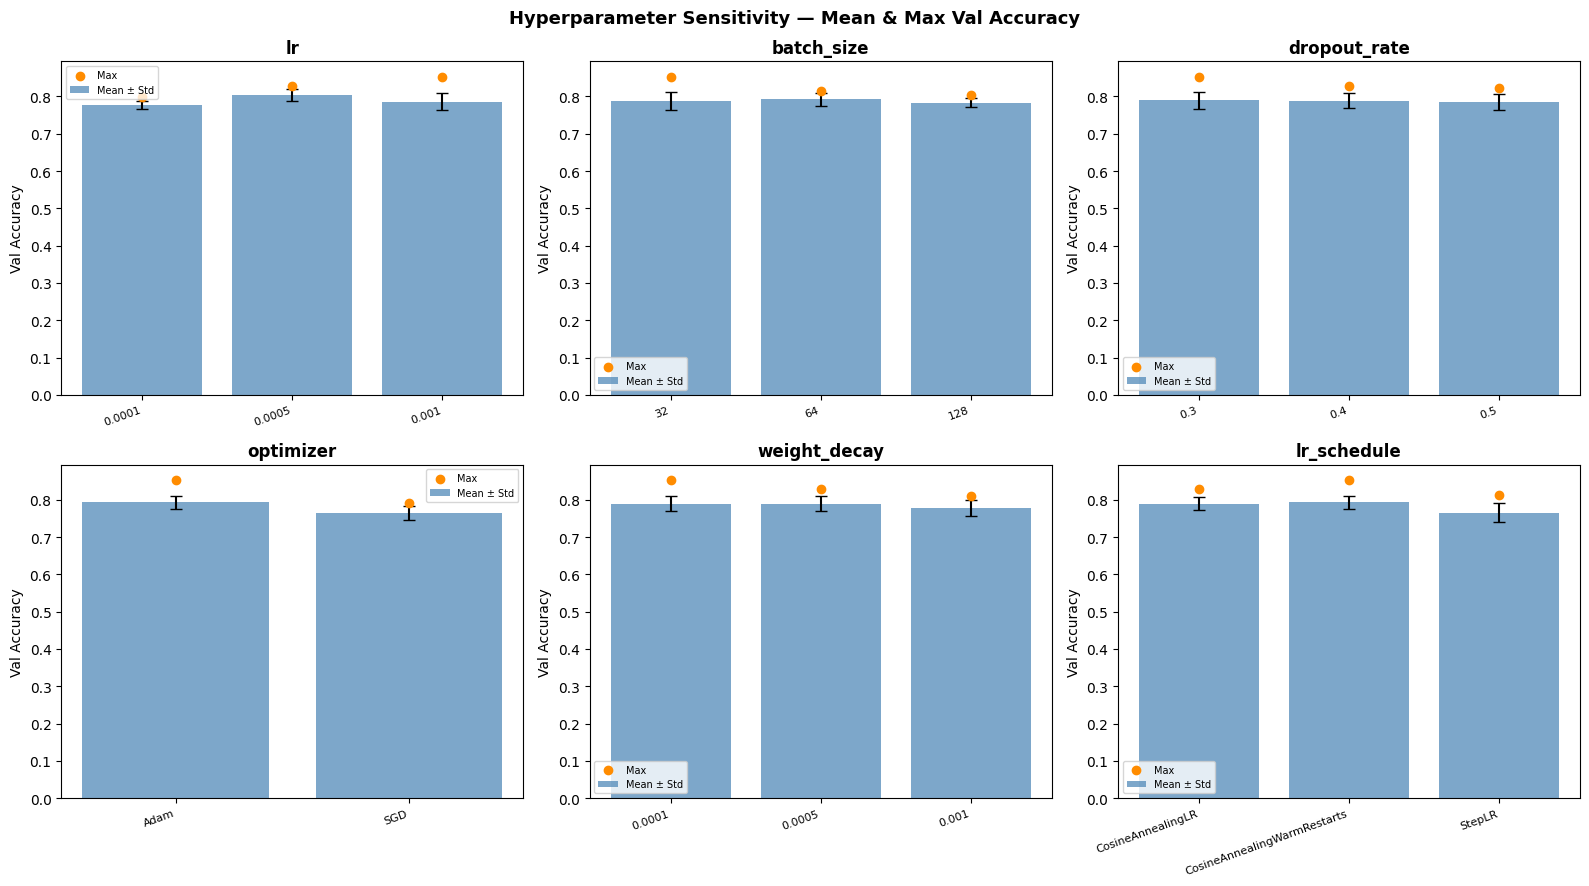

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, param in enumerate(keys):
    grouped = results_df.groupby(param)['best_val_acc'].agg(['mean', 'max', 'std']).reset_index()
    x_labels = grouped[param].astype(str)
    x_pos    = np.arange(len(x_labels))

    axes[ax].bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=4,
                 color='steelblue', alpha=0.7, label='Mean ± Std')
    axes[ax].scatter(x_pos, grouped['max'], color='darkorange', zorder=5, label='Max')
    axes[ax].set_xticks(x_pos)
    axes[ax].set_xticklabels(x_labels, rotation=20, ha='right', fontsize=8)
    axes[ax].set_title(param, fontweight='bold')
    axes[ax].set_ylabel('Val Accuracy')
    axes[ax].legend(fontsize=7)

plt.suptitle('Hyperparameter Sensitivity — Mean & Max Val Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparameter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Learning Curves — Best Configuration (Grid Search Phase)

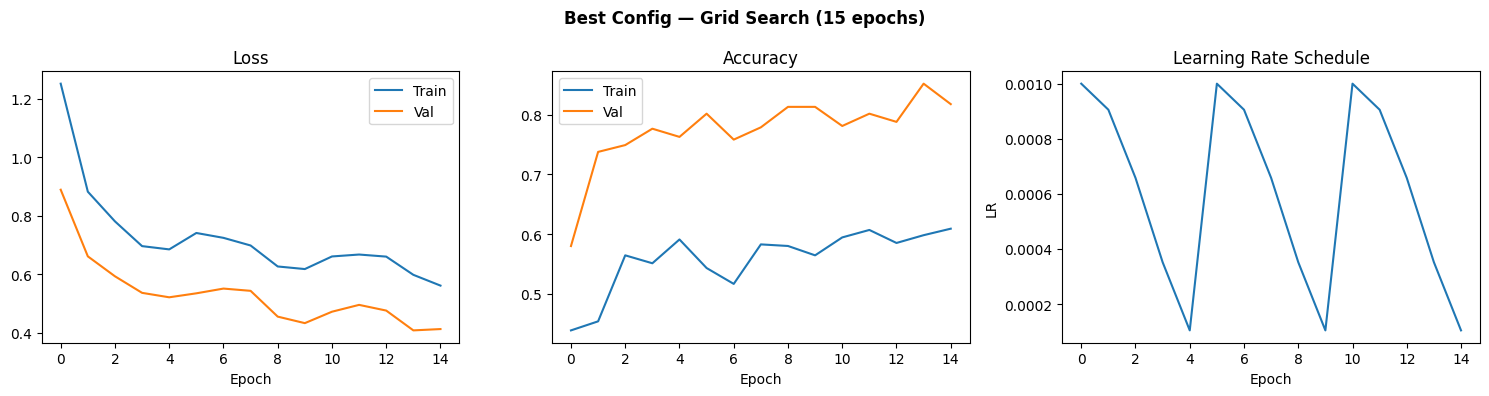

In [24]:
# Retrieve history of the best config from all_results
best_config_key = json.dumps(
    {k: best_config[k] for k in keys},
    sort_keys=True
)
best_run = next(
    r for r in all_results
    if json.dumps(r['config'], sort_keys=True) == best_config_key
)
hist = best_run['history']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(hist['train_loss'], label='Train')
ax1.plot(hist['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(hist['train_acc'], label='Train')
ax2.plot(hist['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

ax3.plot(hist['lr'])
ax3.set_title('Learning Rate Schedule'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')

plt.suptitle(f'Best Config — Grid Search (15 epochs)', fontweight='bold')
plt.tight_layout()
plt.savefig('best_config_grid_search_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Full Retraining — Best Configuration (25 Epochs)

The best configuration is retrained from a fresh random initialisation for the full 25 epochs.

In [25]:
FULL_EPOCHS = 25

print(f'Retraining best configuration for {FULL_EPOCHS} epochs...')
print('Config:', best_config)

full_result = train_one_config(
    best_config,
    num_epochs=FULL_EPOCHS,
    use_mixup=True,
    verbose=True,
)

print(f'\nFull retraining complete. Best val acc: {full_result["best_val_acc"]:.4f}')

# Save tuned model weights
torch.save(full_result['best_weights'], 'tuned_cnn_weights.pth')
print('Weights saved to tuned_cnn_weights.pth')

Retraining best configuration for 25 epochs...
Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'weight_decay': 0.0001, 'lr_schedule': 'CosineAnnealingWarmRestarts'}
  Epoch 01/25

C:\Users\sarth\AppData\Local\Temp\ipykernel_11996\2557066631.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))  # AMP scaler


  →  val_loss=1.1630  val_acc=0.5274
  Epoch 02/25  →  val_loss=0.9093  val_acc=0.6050
  Epoch 03/25  →  val_loss=0.7055  val_acc=0.6918
  Epoch 04/25  →  val_loss=0.5622  val_acc=0.7329
  Epoch 05/25  →  val_loss=0.5536  val_acc=0.7489
  Epoch 06/25  →  val_loss=0.5556  val_acc=0.7717
  Epoch 07/25  →  val_loss=0.6892  val_acc=0.6895
  Epoch 08/25  →  val_loss=0.5863  val_acc=0.7374
  Epoch 09/25  →  val_loss=0.4895  val_acc=0.7877
  Epoch 10/25  →  val_loss=0.4987  val_acc=0.7785
  Epoch 11/25  →  val_loss=0.5334  val_acc=0.7671
  Epoch 12/25  →  val_loss=0.5674  val_acc=0.7489
  Epoch 13/25  →  val_loss=0.4905  val_acc=0.7900
  Epoch 14/25  →  val_loss=0.4624  val_acc=0.8174
  Epoch 15/25  →  val_loss=0.4547  val_acc=0.8128
  Epoch 16/25  →  val_loss=0.6001  val_acc=0.7306
  Epoch 17/25  →  val_loss=0.4934  val_acc=0.7922
  Epoch 18/25  →  val_loss=0.5189  val_acc=0.7831
  Epoch 19/25  →  val_loss=0.4454  val_acc=0.8151
  Epoch 20/25  →  val_loss=0.4278  val_acc=0.8356
  Epoch 21/25

### 8.1 Full Training Curves

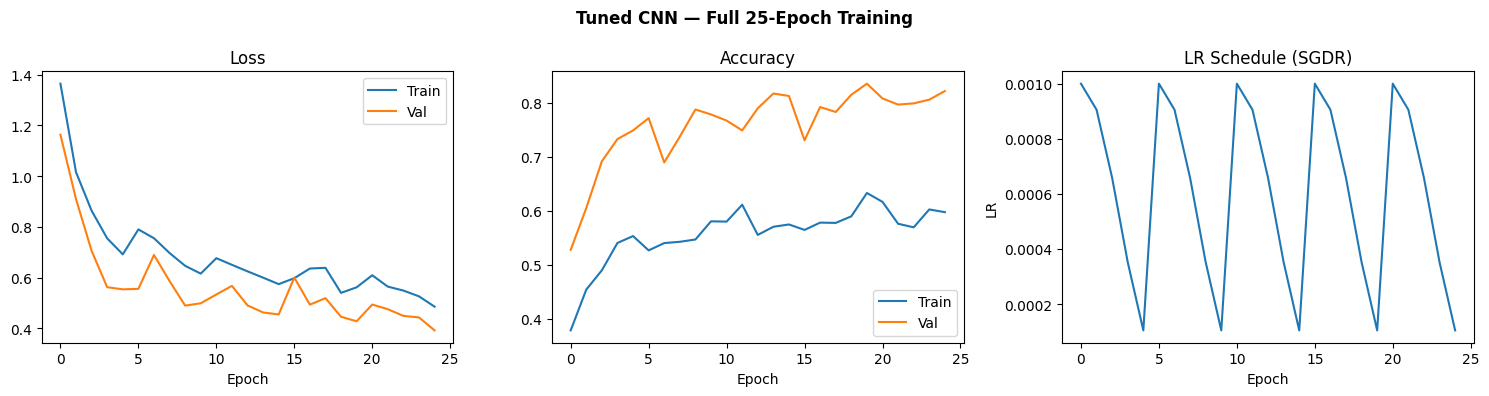

In [26]:
hist_full = full_result['history']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(hist_full['train_loss'], label='Train')
ax1.plot(hist_full['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(hist_full['train_acc'], label='Train')
ax2.plot(hist_full['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

ax3.plot(hist_full['lr'])
ax3.set_title('LR Schedule (SGDR)'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')

plt.suptitle('Tuned CNN — Full 25-Epoch Training', fontweight='bold')
plt.tight_layout()
plt.savefig('tuned_cnn_full_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Test Set Evaluation

Classification Report:
              precision    recall  f1-score   support

       heavy       0.92      0.86      0.89       167
    incident       0.83      0.95      0.88        56
       light       0.93      0.78      0.84       129
    moderate       0.56      0.77      0.65        65

    accuracy                           0.83       417
   macro avg       0.81      0.84      0.82       417
weighted avg       0.85      0.83      0.84       417



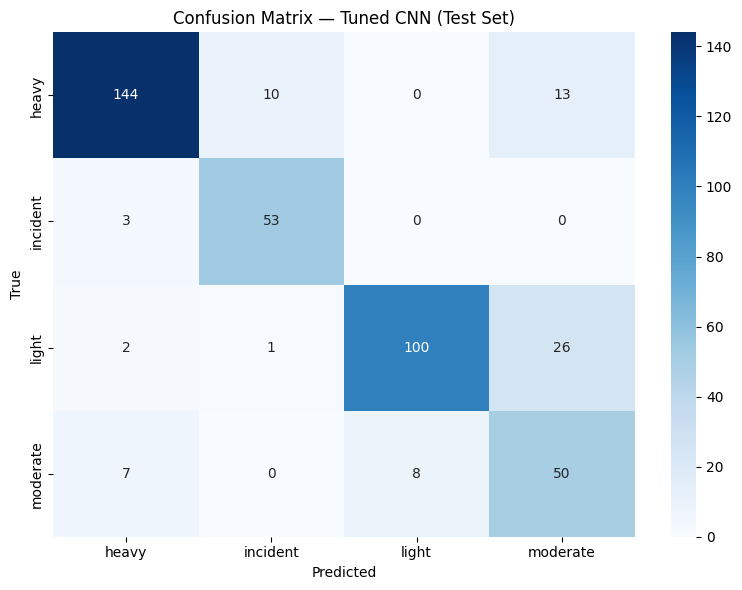

In [27]:
test_loader = DataLoader(
    image_datasets['test'],
    batch_size=best_config['batch_size'],
    shuffle=False,
    num_workers=0,
)

# Rebuild model and load best weights from full retraining
tuned_model = TunableCNN(num_classes=num_classes, dropout_rate=best_config['dropout_rate']).to(device)
tuned_model.load_state_dict(full_result['best_weights'])
tuned_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = tuned_model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Tuned CNN (Test Set)')
plt.tight_layout()
plt.savefig('tuned_cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Baseline vs. Tuned Model — Summary Comparison

In [29]:
# Load baseline results if available (set manually if needed)
# Example: baseline_val_acc = 0.82
baseline_val_acc  = None  # ← set to the baseline val accuracy from the baseline notebook
baseline_test_acc = None  # ← set to the baseline test accuracy from the baseline notebook

tuned_test_acc = sum(p == t for p, t in zip(y_pred, y_true)) / len(y_true)

print('=' * 45)
print(f"{'Metric':<25} {'Baseline':>8} {'Tuned':>8}")
print('-' * 45)
print(f"{'Val Acc (best config)':<25} {str(baseline_val_acc or 'N/A'):>8} {full_result['best_val_acc']:>8.4f}")
print(f"{'Test Acc':<25} {str(baseline_test_acc or 'N/A'):>8} {tuned_test_acc:>8.4f}")
print('=' * 45)

print('\nBest Hyperparameters Found:')
for k, v in best_config.items():
    print(f'  {k:<20}: {v}')

Metric                    Baseline    Tuned
---------------------------------------------
Val Acc (best config)          N/A   0.8356
Test Acc                       N/A   0.8321

Best Hyperparameters Found:
  lr                  : 0.001
  batch_size          : 32
  dropout_rate        : 0.3
  optimizer           : Adam
  weight_decay        : 0.0001
  lr_schedule         : CosineAnnealingWarmRestarts
